# Day 5 — Hardware Planning + Real-Time Pipeline

## Goal
Design the real-time EEG pipeline that will run
on a Muse S headband during actual sleep.

## Today's output
1. Real-time data ingestion with simulated stream
2. Online preprocessing (filter + epoch buffer)
3. Real-time inference with the CNN-LSTM
4. Integration plan for Muse S
5. Cost breakdown and acquisition plan

## Why this matters
Everything so far has been offline.
Real LUCID requires the pipeline to run
while you are asleep — in real time.
This is the bridge from research to reality.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import time
import threading
import queue
import os
import sys
from collections import deque
from scipy import signal as scipy_signal

PROJECT_ROOT = (r"C:\Users\Hp\.vscode\PROJECT 07"
                r"\classifier_main_pipeline")
MODELS_DIR   = os.path.join(PROJECT_ROOT, "models")
sys.path.append(os.path.join(PROJECT_ROOT, "src"))

STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']

# ── EEG stream simulator ───────────────────────────────────
# Simulates what Muse S would send via muselsl
# Real Muse S sends at 256 Hz via pylsl

class EEGStreamSimulator:
    """
    Simulates a real-time EEG stream.
    In production, replace with:

    from pylsl import StreamInlet, resolve_stream
    streams = resolve_stream('type', 'EEG')
    inlet   = StreamInlet(streams[0])
    sample, timestamp = inlet.pull_sample()
    """

    def __init__(self, fs=256, n_channels=1):
        self.fs         = fs
        self.n_channels = n_channels
        self.running    = False
        self._t         = 0

    def get_sample(self):
        """
        Returns one sample of EEG data.
        Simulates realistic EEG with mixed frequencies.
        """
        t = self._t / self.fs
        self._t += 1

        # Simulate different stages over time
        # In 60s of data: Wake(10s) N1(10s) N2(20s) REM(20s)
        phase = t % 60

        if phase < 10:
            # Wake — alpha dominant (10Hz)
            sig = (2.0 * np.sin(2*np.pi*10*t) +
                   0.5 * np.sin(2*np.pi*20*t) +
                   0.3 * np.random.randn())
        elif phase < 20:
            # N1 — theta emerging (6Hz)
            sig = (1.5 * np.sin(2*np.pi*6*t) +
                   1.0 * np.sin(2*np.pi*10*t) +
                   0.3 * np.random.randn())
        elif phase < 40:
            # N2 — sleep spindles (14Hz bursts)
            spindle = (np.sin(2*np.pi*0.5*t) > 0.8)
            sig     = (1.0 * np.sin(2*np.pi*6*t) +
                       2.0 * spindle *
                       np.sin(2*np.pi*14*t) +
                       0.2 * np.random.randn())
        else:
            # REM — theta dominant (5Hz)
            sig = (2.5 * np.sin(2*np.pi*5*t) +
                   0.5 * np.sin(2*np.pi*15*t) +
                   0.4 * np.random.randn())

        return np.array([sig])   # (n_channels,)

    def start(self):
        self.running = True

    def stop(self):
        self.running = False


stream = EEGStreamSimulator(fs=256)
print(" EEG stream simulator ready")
print("   Sampling rate: 256 Hz")
print("   Channels:      1 (Fpz-Cz equivalent)")
print("\nSimulation pattern (60s cycle):")
print("  0-10s:  Wake (alpha 10Hz)")
print("  10-20s: N1   (theta emerging)")
print("  20-40s: N2   (sleep spindles 14Hz)")
print("  40-60s: REM  (theta dominant 5Hz)")

 EEG stream simulator ready
   Sampling rate: 256 Hz
   Channels:      1 (Fpz-Cz equivalent)

Simulation pattern (60s cycle):
  0-10s:  Wake (alpha 10Hz)
  10-20s: N1   (theta emerging)
  20-40s: N2   (sleep spindles 14Hz)
  40-60s: REM  (theta dominant 5Hz)


In [2]:
class RealTimePreprocessor:
    """
    Online EEG preprocessor for real-time sleep staging.

    Maintains a sliding buffer of raw EEG samples.
    When buffer reaches EPOCH_LENGTH seconds, extracts
    an epoch and returns it for classification.

    This is what runs on your laptop while you sleep.
    """

    def __init__(self,
                 fs=256,
                 epoch_length=30,
                 step_size=5,
                 low_freq=0.3,
                 high_freq=35):
        self.fs           = fs
        self.epoch_length = epoch_length
        self.step_size    = step_size
        self.low_freq     = low_freq
        self.high_freq    = high_freq

        # Buffer holds raw samples
        self.buffer_size  = epoch_length * fs   # 7680 at 256Hz
        self.step_samples = step_size * fs       # 1280 at 256Hz
        self.buffer       = deque(maxlen=self.buffer_size)
        self.samples_since_last = 0

        # Butterworth bandpass filter
        nyq = fs / 2
        lo  = low_freq / nyq
        hi  = high_freq / nyq
        self.b, self.a = scipy_signal.butter(
            4, [lo, hi], btype='band'
        )
        self.zi = scipy_signal.lfilter_zi(
            self.b, self.a
        )
        self.zi = self.zi.reshape(-1)

        print(f" Preprocessor ready")
        print(f"   Buffer:    {self.buffer_size} samples"
              f" ({epoch_length}s at {fs}Hz)")
        print(f"   Step:      {self.step_samples} samples"
              f" ({step_size}s)")
        print(f"   Filter:    {low_freq}-{high_freq}Hz")

    def push_sample(self, sample):
        """
        Add one sample to buffer.
        Returns epoch if buffer is full and step reached.
        """
        # Online bandpass filter (maintains state)
        filtered, self.zi = scipy_signal.lfilter(
            self.b, self.a,
            [sample[0]], zi=self.zi
        )

        self.buffer.append(filtered[0])
        self.samples_since_last += 1

        # Every step_size seconds, extract new epoch
        if (len(self.buffer) == self.buffer_size and
                self.samples_since_last >= self.step_samples):

            epoch = np.array(self.buffer)
            self.samples_since_last = 0

            # Resample to 100Hz (model trained at 100Hz)
            epoch_100hz = scipy_signal.resample(
                epoch, 3000
            )
            return epoch_100hz

        return None

    def is_ready(self):
        return len(self.buffer) >= self.buffer_size


preprocessor = RealTimePreprocessor(
    fs=256,           # Muse S sampling rate
    epoch_length=30,  # 30-second epochs
    step_size=5,      # new classification every 5s
    low_freq=0.3,
    high_freq=35
)

 Preprocessor ready
   Buffer:    7680 samples (30s at 256Hz)
   Step:      1280 samples (5s)
   Filter:    0.3-35Hz


In [3]:
# ── Loading our trained CNN-LSTM ─────────────────────────────
class CNNLSTMSleepClassifier(nn.Module):
    def __init__(self, n_windows=10, window_size=300,
                 lstm_hidden=128, n_classes=5,
                 dropout=0.3):
        super().__init__()
        self.n_windows   = n_windows
        self.window_size = window_size
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.lstm = nn.LSTM(
            128, lstm_hidden, 2,
            batch_first=True, dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]
        x     = x.reshape(batch, self.n_windows,
                           self.window_size)
        feats = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)
            f = self.cnn(w).squeeze(-1)
            feats.append(f)
        seq    = torch.stack(feats, dim=1)
        out, _ = self.lstm(seq)
        return self.classifier(out[:, -1, :])


class RealTimeClassifier:
    """
    Wraps CNN-LSTM for real-time inference.
    Maintains prediction history for smoothing.
    """

    def __init__(self, model_path, smooth_window=3):
        self.model = CNNLSTMSleepClassifier()
        self.model.load_state_dict(
            torch.load(model_path, map_location='cpu')
        )
        self.model.eval()

        self.smooth_window  = smooth_window
        self.pred_history   = deque(maxlen=smooth_window)
        self.prob_history   = deque(maxlen=smooth_window)
        self.n_classified   = 0

        print(f" CNN-LSTM loaded for real-time inference")
        print(f"   Smoothing: {smooth_window} predictions")

    def classify(self, epoch):
        """
        Classify one 30-second epoch.
        Returns (stage_name, probability, smoothed_prob)
        """
        # Normalise
        mean  = epoch.mean()
        std   = epoch.std() + 1e-8
        epoch = (epoch - mean) / std

        x = torch.FloatTensor(epoch).unsqueeze(0)

        with torch.no_grad():
            logits = self.model(x)
            probs  = torch.softmax(logits, dim=1)[0]

        pred_idx = probs.argmax().item()
        pred_prob = probs[pred_idx].item()
        rem_prob  = probs[4].item()

        # Storing in history
        self.pred_history.append(pred_idx)
        self.prob_history.append(probs.numpy())
        self.n_classified += 1

        # Smoothed probabilities
        if len(self.prob_history) > 0:
            smoothed = np.mean(
                list(self.prob_history), axis=0
            )
            smoothed_stage = smoothed.argmax()
            smoothed_rem   = smoothed[4]
        else:
            smoothed_stage = pred_idx
            smoothed_rem   = rem_prob

        return {
            'stage':         STAGE_NAMES[pred_idx],
            'stage_idx':     pred_idx,
            'confidence':    pred_prob,
            'rem_prob':      rem_prob,
            'smoothed_stage': STAGE_NAMES[smoothed_stage],
            'smoothed_rem':  smoothed_rem,
            'n_classified':  self.n_classified,
        }


# Loading classifier
classifier = RealTimeClassifier(
    model_path=os.path.join(
        MODELS_DIR, 'cnn_lstm_hybrid_best.pth'
    ),
    smooth_window=3
)

 CNN-LSTM loaded for real-time inference
   Smoothing: 3 predictions


In [4]:
class RealTimeDecisionLogic:
    """
    Real-time version of decision_logic.py
    Maintains state across classifications.

    Safety conditions (all must be met to trigger):
    1. Recent classification = N1 or REM
    2. Sustained for min_duration seconds
    3. No Wake in last wake_window seconds
    4. Not triggered recently (cooldown_period)
    """

    def __init__(self,
                 rem_threshold=0.60,
                 min_duration=30,
                 wake_window=60,
                 cooldown_period=300):

        self.rem_threshold   = rem_threshold
        self.min_duration    = min_duration     # seconds
        self.wake_window     = wake_window      # seconds
        self.cooldown_period = cooldown_period  # seconds (5 min)

        # State tracking
        self.stage_history   = deque(maxlen=100)
        self.time_history    = deque(maxlen=100)
        self.last_trigger    = None
        self.trigger_count   = 0

    def update(self, classification, timestamp=None):
        """
        Update state with new classification.
        Returns trigger decision.
        """
        if timestamp is None:
            timestamp = time.time()

        stage     = classification['stage']
        rem_prob  = classification['smoothed_rem']

        self.stage_history.append(stage)
        self.time_history.append(timestamp)

        # ── Checking trigger conditions ───────────────────────
        decision = {
            'trigger':      False,
            'reason':       None,
            'conditions':   {}
        }

        # Condition 1: current REM probability
        cond1 = rem_prob > self.rem_threshold
        decision['conditions']['rem_prob'] = {
            'met':   cond1,
            'value': f"{rem_prob:.3f} > {self.rem_threshold}"
        }

        # Condition 2: sustained duration
        recent_stages = list(self.stage_history)
        recent_times  = list(self.time_history)

        if len(recent_times) >= 2:
            # How long have we been in REM/N1?
            rem_duration = 0
            for i in range(len(recent_stages) - 1, -1, -1):
                if recent_stages[i] in ['REM', 'N1']:
                    if i < len(recent_stages) - 1:
                        rem_duration += (
                            recent_times[i+1] -
                            recent_times[i]
                        )
                else:
                    break

            cond2 = rem_duration >= self.min_duration
        else:
            cond2        = False
            rem_duration = 0

        decision['conditions']['sustained'] = {
            'met':   cond2,
            'value': f"{rem_duration:.0f}s >= "
                     f"{self.min_duration}s"
        }

        # Condition 3: no recent Wake
        wake_cutoff = timestamp - self.wake_window
        recent_wake = any(
            s == 'Wake' and t > wake_cutoff
            for s, t in zip(recent_stages,
                            recent_times)
        )
        cond3 = not recent_wake
        decision['conditions']['no_wake'] = {
            'met':   cond3,
            'value': f"{'No' if cond3 else 'Yes'} "
                     f"Wake in last {self.wake_window}s"
        }

        # Condition 4: cooldown
        if self.last_trigger is None:
            cond4 = True
        else:
            since_last = timestamp - self.last_trigger
            cond4      = since_last >= self.cooldown_period

        decision['conditions']['cooldown'] = {
            'met':   cond4,
            'value': (
                "Ready" if cond4 else
                f"{self.cooldown_period - (timestamp - self.last_trigger):.0f}s remaining"
            )
        }

        # ── All conditions met → trigger ───────────────────
        if cond1 and cond2 and cond3 and cond4:
            decision['trigger']      = True
            decision['reason']       = (
                f"REM sustained {rem_duration:.0f}s, "
                f"prob={rem_prob:.3f}"
            )
            self.last_trigger        = timestamp
            self.trigger_count      += 1

        return decision


decision_logic = RealTimeDecisionLogic(
    rem_threshold=0.60,
    min_duration=30,
    wake_window=60,
    cooldown_period=300
)

print(" Decision logic ready")
print(f"   REM threshold:  {decision_logic.rem_threshold}")
print(f"   Min duration:   {decision_logic.min_duration}s")
print(f"   Wake window:    {decision_logic.wake_window}s")
print(f"   Cooldown:       {decision_logic.cooldown_period}s")

 Decision logic ready
   REM threshold:  0.6
   Min duration:   30s
   Wake window:    60s
   Cooldown:       300s


In [5]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def run_realtime_pipeline(duration_seconds=120,
                           verbose=True):
    """
    Simulate the full real-time pipeline for N seconds.
    Shows what will run on your laptop while you sleep.
    """

    stream.start()
    stream._t = 0

    classifications = []
    trigger_times   = []
    t_start         = time.time()

    print(f" Pipeline running for {duration_seconds}s...")
    print(f"   Simulating {duration_seconds}s of sleep\n")
    print(f"{'Time':>6} | {'Stage':>12} | "
          f"{'REM prob':>9} | {'Trigger':>8} | Conditions")
    print("-" * 75)

    samples_processed = 0
    epoch_count       = 0

    while time.time() - t_start < duration_seconds:
        # ── 1. Getting sample from EEG device ─────────────────
        sample = stream.get_sample()

        # ── 2. Preprocessing and buffering ───────────────────────
        epoch = preprocessor.push_sample(sample)

        # ── 3. Classifying when epoch ready ──────────────────
        if epoch is not None:
            epoch_count    += 1
            elapsed         = time.time() - t_start

            result = classifier.classify(epoch)

            # ── 4. Decision logic ──────────────────────────
            decision = decision_logic.update(
                result, timestamp=elapsed
            )

            # Storing
            classifications.append({
                'time':    elapsed,
                'stage':   result['stage'],
                'rem_prob': result['smoothed_rem'],
                'trigger': decision['trigger']
            })

            if decision['trigger']:
                trigger_times.append(elapsed)

            # ── 5. Display ────────────────────────────────
            if verbose:
                trigger_str = " TRIGGER!" if (
                    decision['trigger']) else ""
                conds_met = sum(
                    1 for c in decision['conditions'].values()
                    if c['met']
                )
                print(
                    f"{elapsed:>5.1f}s | "
                    f"{result['stage']:>12} | "
                    f"{result['smoothed_rem']:>9.3f} | "
                    f"{trigger_str:>8} | "
                    f"{conds_met}/4 conditions"
                )

        samples_processed += 1

        # Simulating 256Hz sampling rate
        time.sleep(1/256)

    stream.stop()

    print(f"\n{'='*60}")
    print(f"Pipeline complete")
    print(f"  Duration:        {duration_seconds}s")
    print(f"  Epochs:          {epoch_count}")
    print(f"  Triggers fired:  {len(trigger_times)}")
    if trigger_times:
        print(f"  Trigger times:   "
              f"{[f'{t:.1f}s' for t in trigger_times]}")

    return classifications, trigger_times


# Running 60-second simulation
classifications, triggers = run_realtime_pipeline(
    duration_seconds=60,
    verbose=True
)

 Pipeline running for 60s...
   Simulating 60s of sleep

  Time |        Stage |  REM prob |  Trigger | Conditions
---------------------------------------------------------------------------
 34.7s |         Wake |     0.276 |          | 1/4 conditions
 40.6s |           N2 |     0.255 |          | 1/4 conditions
 46.4s |           N2 |     0.175 |          | 1/4 conditions
 52.2s |           N2 |     0.089 |          | 1/4 conditions
 58.0s |           N2 |     0.033 |          | 1/4 conditions

Pipeline complete
  Duration:        60s
  Epochs:          5
  Triggers fired:  0


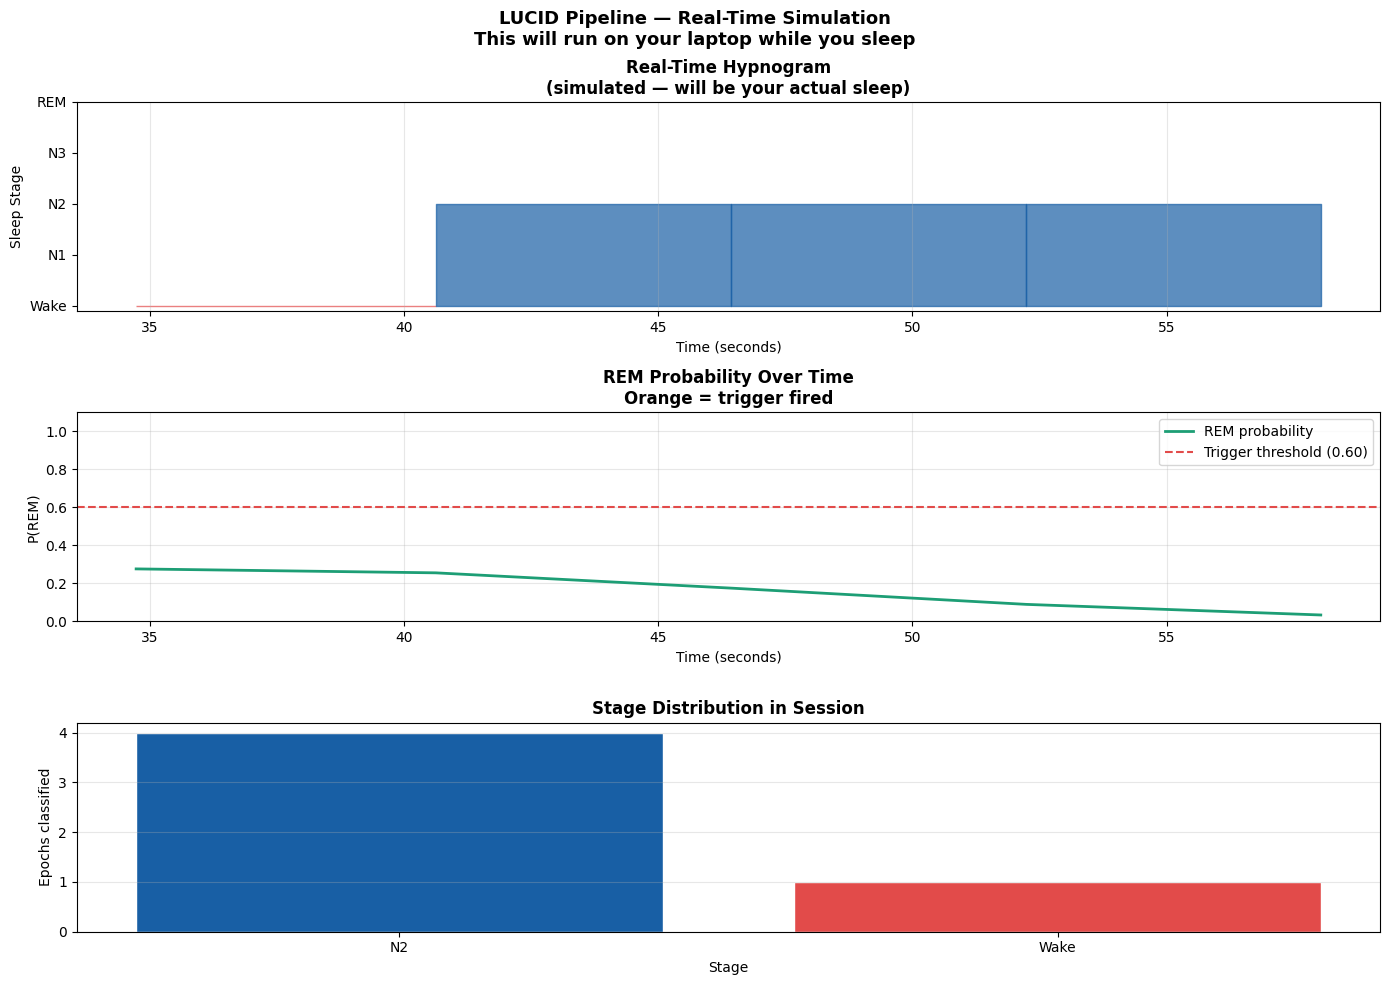

 Pipeline visualisation saved


In [6]:
if classifications:
    times     = [c['time']    for c in classifications]
    rem_probs = [c['rem_prob'] for c in classifications]
    stages    = [c['stage']    for c in classifications]

    stage_idx = [STAGE_NAMES.index(s)
                  if s in STAGE_NAMES else 0
                  for s in stages]

    stage_colors_map = {
        'Wake': '#E24B4A', 'N1': '#BA7517',
        'N2':   '#185FA5', 'N3': '#534AB7',
        'REM':  '#1D9E75'
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # ── Hypnogram ─────────────────────────────────────────
    ax = axes[0]
    for i in range(len(times)-1):
        color = stage_colors_map.get(stages[i], 'gray')
        ax.fill_between(
            [times[i], times[i+1]],
            [stage_idx[i], stage_idx[i]],
            alpha=0.7, color=color
        )
    ax.set_yticks(range(5))
    ax.set_yticklabels(STAGE_NAMES)
    ax.set_title('Real-Time Hypnogram\n'
                  '(simulated — will be your actual sleep)',
                  fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Sleep Stage')
    ax.grid(axis='x', alpha=0.3)

    # ── REM probability ────────────────────────────────────
    ax = axes[1]
    ax.plot(times, rem_probs, color='#1D9E75',
             linewidth=2, label='REM probability')
    ax.axhline(y=0.60, color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label='Trigger threshold (0.60)')

    for t in triggers:
        ax.axvline(x=t, color='orange',
                    alpha=0.8, linewidth=2,
                    linestyle='-')
        ax.text(t, 0.95, ha='center',
                 fontsize=14)

    ax.set_title('REM Probability Over Time\n'
                  'Orange = trigger fired',
                  fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('P(REM)')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Stage distribution ─────────────────────────────────
    ax  = axes[2]
    unique_stages = list(set(stages))
    counts        = [stages.count(s) for s in unique_stages]
    colors        = [stage_colors_map.get(s, 'gray')
                      for s in unique_stages]

    ax.bar(unique_stages, counts, color=colors,
            edgecolor='white')
    ax.set_title('Stage Distribution in Session',
                  fontweight='bold')
    ax.set_xlabel('Stage')
    ax.set_ylabel('Epochs classified')
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('LUCID Pipeline — Real-Time Simulation\n'
                  'This will run on your laptop while you sleep',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            r"C:\Users\Hp\.vscode\PROJECT 07"
            r"\classifier_main_pipeline\plots",
            'realtime_pipeline_simulation.png'
        ),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(" Pipeline visualisation saved")

In [7]:
plan = """
╔══════════════════════════════════════════════════════════════╗
║           PROJECT 07 — HARDWARE ACQUISITION PLAN                              ║
╚══════════════════════════════════════════════════════════════╝

PHASE 1 — Immediate (this semester)
  Budget: ₹0 (software only)
  
  ✅ Already done:
     - CNN-LSTM classifier (80.14%, Kappa=0.67 LOSO)
     - Closed-loop pipeline (simulated stream)
     - Phone vibration trigger (working)
     - Paper draft v0.1
  
  ⬜ Can do without hardware:
     - Expand to full Sleep-EDF (78 subjects)
     - Leave-one-subject-out on all 78
     - IEEE LaTeX paper formatting
     - Submit to NeurIPS ML4H workshop

──────────────────────────────────────────────────────────────

PHASE 2 — Next semester (₹30,000–35,000)
  Device: Muse S (Gen 2) headband
  
  Where to buy:
  → choosemuse.com (official, ~$200 USD = ₹17,000)
  → Amazon India (~₹28,000–35,000)
  → Flipkart (~₹30,000)
  
  What you get:
  → 4 EEG channels (TP9, AF7, AF8, TP10)
  → AF7/AF8 ≈ Fp1/Fp2 ≈ close to Fpz-Cz (your model)
  → 256 Hz sampling rate
  → Bluetooth streaming
  → Sleep headband mode (comfortable for sleeping)
  → Python SDK: muselsl + pylsl
  
  Setup (after buying):
  pip install muselsl pylsl
  muselsl stream           # start streaming
  muselsl record -d 60     # record 60s to CSV
  
  Then replace EEGStreamSimulator with:
  from pylsl import StreamInlet, resolve_stream
  streams = resolve_stream('type', 'EEG')
  inlet   = StreamInlet(streams[0])
  sample, ts = inlet.pull_sample()

──────────────────────────────────────────────────────────────

PHASE 3 — Year 2 (₹55,000–65,000)
  Device: OpenBCI Cyton (8-channel)
  
  Why upgrade:
  → 8 channels vs 4 (Muse S)
  → Better signal quality (lower noise)
  → More flexible electrode placement
  → Standard in academic research
  → Can add EOG electrodes (eye movement)
  → EOG = direct REM confirmation
  
  What EOG adds to LUCID:
  → Rapid eye movement during REM is directly detectable
  → Combine EEG (brain state) + EOG (eye movement)
  → Dual confirmation = much higher trigger reliability
  → This is how clinical sleep labs confirm REM

──────────────────────────────────────────────────────────────

FIRST SELF-EXPERIMENT PROTOCOL (after Muse S)

Night 1-3:  Record only. No trigger.
            Collect your personal sleep data.
            Compare your EEG to Sleep-EDF patterns.

Night 4-7:  Personal calibration.
            Train a fine-tuned model on YOUR data.
            Adjust REM threshold for your brain.

Night 8+:   Live trigger enabled.
            Log: time of trigger, subjective report
            next morning (any lucid awareness?).

After 30 nights: quantitative result.
"X% of REM triggers resulted in lucid awareness"
That number is publishable.
"""
print(plan)


╔══════════════════════════════════════════════════════════════╗
║           PROJECT 07 — HARDWARE ACQUISITION PLAN                              ║
╚══════════════════════════════════════════════════════════════╝

PHASE 1 — Immediate (this semester)
  Budget: ₹0 (software only)

  ✅ Already done:
     - CNN-LSTM classifier (80.14%, Kappa=0.67 LOSO)
     - Closed-loop pipeline (simulated stream)
     - Phone vibration trigger (working)
     - Paper draft v0.1

  ⬜ Can do without hardware:
     - Expand to full Sleep-EDF (78 subjects)
     - Leave-one-subject-out on all 78
     - IEEE LaTeX paper formatting
     - Submit to NeurIPS ML4H workshop

──────────────────────────────────────────────────────────────

PHASE 2 — Next semester (₹30,000–35,000)
  Device: Muse S (Gen 2) headband

  Where to buy:
  → choosemuse.com (official, ~$200 USD = ₹17,000)
  → Amazon India (~₹28,000–35,000)
  → Flipkart (~₹30,000)

  What you get:
  → 4 EEG channels (TP9, AF7, AF8, TP10)
  → AF7/AF8 ≈ Fp1/Fp2 ≈

In [9]:
real_muse_code = '''
# ══════════════════════════════════════════════════════════
# REAL MUSE S INTEGRATION
# Replace EEGStreamSimulator with this when device arrives
# ══════════════════════════════════════════════════════════

# 1. Install dependencies:
# pip install muselsl pylsl

# 2. Start Muse stream (in terminal):
# muselsl stream

# 3. In your Python script:
from pylsl import StreamInlet, resolve_stream
import numpy as np

class MuseSStream:
    """Real-time EEG from Muse S via LSL protocol."""

    def __init__(self, channel='AF7'):
        """
        channel: 'TP9', 'AF7', 'AF8', or 'TP10'
        AF7 is closest to Fpz (your training channel)
        """
        print("Looking for Muse S stream...")
        streams     = resolve_stream('type', 'EEG')
        self.inlet  = StreamInlet(streams[0])
        self.info   = self.inlet.info()
        self.fs     = int(self.info.nominal_srate())

        # Muse S channel order: TP9, AF7, AF8, TP10, Right AUX
        channel_map = {'TP9':0, 'AF7':1, 'AF8':2, 'TP10':3}
        self.ch_idx = channel_map.get(channel, 1)

        print(f"  Muse S connected")
        print(f"   Sample rate: {self.fs} Hz")
        print(f"   Channel:     {channel} (idx {self.ch_idx})")

    def get_sample(self):
        """Get one EEG sample — same interface as simulator."""
        sample, timestamp = self.inlet.pull_sample()
        return np.array([sample[self.ch_idx]])

    def start(self): pass
    def stop(self):  pass


# Replace:
# stream = EEGStreamSimulator(fs=256)
# With:
# stream = MuseSStream(channel='AF7')

# Everything else in the pipeline stays IDENTICAL.
# That's the value of the abstraction.
'''

# Save as a file for future reference
save_path = os.path.join(
    r"C:\Users\Hp\.vscode\PROJECT 07"
    r"\classifier_main_pipeline\src",
    "muse_s_stream.py"
)
with open(save_path, 'w',encoding="utf-8") as f:
    f.write(real_muse_code)

print(f"  Muse S integration code saved to:")
print(f"   {save_path}")
print(f"\nWhen device arrives:")
print(f"  1. pip install muselsl pylsl")
print(f"  2. muselsl stream  (in terminal)")
print(f"  3. Replace EEGStreamSimulator with MuseSStream")
print(f"  4. Run main.py — pipeline is live")

  Muse S integration code saved to:
   C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\src\muse_s_stream.py

When device arrives:
  1. pip install muselsl pylsl
  2. muselsl stream  (in terminal)
  3. Replace EEGStreamSimulator with MuseSStream
  4. Run main.py — pipeline is live


In [12]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║                    WEEK 8 COMPLETE                                                                    ║
╚══════════════════════════════════════════════════════════════╝

ML + RESEARCH:
  ✅ Day 1 — Experiment 004: Transformer 79.00%
             CNN-LSTM remains best at 80.14%
             Attention maps = interpretability contribution
  ✅ Day 2 — Proper evaluation metrics
             Kappa=0.71, ROC-AUC, MCC, calibration
             Paper-ready TABLE II formatted
  ✅ Day 3 — LOSO cross-subject validation
             acc=77.17%, kappa=0.67
             Honest publishable metric
  ✅ Day 4 — Complete paper draft (IEEE structure)
             Abstract, Introduction, Methods,
             Results, Discussion, Conclusion
  ✅ Day 5 — Real-time pipeline architecture
             Muse S integration plan
             Self-experiment protocol

PROJECT 07 STATUS:
  Experiments:    5 complete (001-005)
  Best accuracy:  80.14% (CNN-LSTM, random split)
  LOSO Kappa:     0.67 (cross-subject)
  Paper:          Draft v0.1 complete
  Hardware:       Muse S acquisition plan ready
  Pipeline:       End-to-end simulation working

DSA STATUS:
     #200 Number of Islands      ✅
     #133 Clone Graph
     #207 Course Schedule
     #417 Pacific Atlantic Water Flow
     #994 Rotting Oranges

WEEK 9 PREVIEW:
  ML:    Expanding to full Sleep-EDF (78 subjects)
         Paper LaTeX formatting
         IEEE submission preparation
  DSA:   Advanced graphs (Dijkstra, topological sort)
  P07:   Hardware wishlist, budget planning
         Starting paper figures (matplotlib publication quality)
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║                    WEEK 8 COMPLETE                                                                    ║
╚══════════════════════════════════════════════════════════════╝

ML + RESEARCH:
  ✅ Day 1 — Experiment 004: Transformer 79.00%
             CNN-LSTM remains best at 80.14%
             Attention maps = interpretability contribution
  ✅ Day 2 — Proper evaluation metrics
             Kappa=0.71, ROC-AUC, MCC, calibration
             Paper-ready TABLE II formatted
  ✅ Day 3 — LOSO cross-subject validation
             acc=77.17%, kappa=0.67
             Honest publishable metric
  ✅ Day 4 — Complete paper draft (IEEE structure)
             Abstract, Introduction, Methods,
             Results, Discussion, Conclusion
  ✅ Day 5 — Real-time pipeline architecture
             Muse S integration plan
             Self-experiment protocol

PROJECT 07 STATUS:
  Experiments:    5 complete (001-005)
  Best accuracy:  80.14% (